# Tutorial 03 — Trích Đặc Trưng (Feature Engineering) Cho Chẩn Đoán Ổ Lăn

> **Mục tiêu:** Chuyển tín hiệu rung thô thành bảng số (features) để đưa vào ML.
> 3 nhóm feature: Thời gian + Tần số + **Envelope** (cốt lõi chẩn đoán ổ lăn).

---

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
os.makedirs('../figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.signal_utils import load_cwru_data
from src.features import extract_features, time_domain_features, frequency_domain_features, envelope_features

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style("whitegrid")
print("✅ Import thành công.")

✅ Import thành công.


## 1. Load Dữ Liệu & Cắt Segment

Mỗi file tín hiệu dài được cắt thành các segment ngắn (2048 mẫu, overlap 50%).
Hàm `load_cwru_data()` trả về thêm `file_ids` để split đúng cách ở Tutorial 04.

In [2]:
X_raw, y_raw, file_ids = load_cwru_data()
print(f"\nTổng: {len(X_raw)} segments, mỗi segment {X_raw.shape[1]} mẫu")
print(f"File IDs duy nhất: {len(np.unique(file_ids))}")


📂 0HP: tìm thấy 14 file .npy
   ✅ B_007_DE.npy: 244,739 mẫu → 28 segments [B]
   ✅ B_014_DE.npy: 249,146 mẫu → 29 segments [B]
   ✅ B_021_DE.npy: 243,938 mẫu → 28 segments [B]
   ✅ IR_007_DE.npy: 243,938 mẫu → 28 segments [IR]
   ✅ IR_014_DE.npy: 63,788 mẫu → 6 segments [IR]
   ✅ IR_021_DE.npy: 244,339 mẫu → 28 segments [IR]
   ✅ Normal_DE.npy: 243,938 mẫu → 28 segments [Normal]
   ✅ OR_007@12_DE.npy: 129,969 mẫu → 14 segments [OR]
   ✅ OR_007@3_DE.npy: 124,602 mẫu → 14 segments [OR]
   ✅ OR_007@6_DE.npy: 243,538 mẫu → 28 segments [OR]
   ✅ OR_014@6_DE.npy: 245,140 mẫu → 28 segments [OR]
   ✅ OR_021@12_DE.npy: 130,549 mẫu → 14 segments [OR]
   ✅ OR_021@3_DE.npy: 128,663 mẫu → 14 segments [OR]
   ✅ OR_021@6_DE.npy: 246,342 mẫu → 29 segments [OR]

📂 1HP: tìm thấy 14 file .npy
   ✅ B_007_DE.npy: 487,384 mẫu → 58 segments [B]


   ✅ B_014_DE.npy: 486,224 mẫu → 58 segments [B]
   ✅ B_021_DE.npy: 486,804 mẫu → 58 segments [B]
   ✅ IR_007_DE.npy: 486,224 mẫu → 58 segments [IR]
   ✅ IR_014_DE.npy: 489,125 mẫu → 58 segments [IR]
   ✅ IR_021_DE.npy: 485,063 mẫu → 58 segments [IR]
   ✅ Normal_DE.npy: 483,903 mẫu → 58 segments [Normal]
   ✅ OR_007@12_DE.npy: 482,742 mẫu → 57 segments [OR]
   ✅ OR_007@3_DE.npy: 485,063 mẫu → 58 segments [OR]
   ✅ OR_007@6_DE.npy: 486,804 mẫu → 58 segments [OR]
   ✅ OR_014@6_DE.npy: 484,483 mẫu → 58 segments [OR]


   ✅ OR_021@12_DE.npy: 486,224 mẫu → 58 segments [OR]
   ✅ OR_021@3_DE.npy: 489,705 mẫu → 58 segments [OR]
   ✅ OR_021@6_DE.npy: 489,125 mẫu → 58 segments [OR]

📂 2HP: tìm thấy 14 file .npy
   ✅ B_007_DE.npy: 486,804 mẫu → 58 segments [B]
   ✅ B_014@6_DE.npy: 486,804 mẫu → 58 segments [B]
   ✅ B_014_DE.npy: 487,384 mẫu → 58 segments [B]
   ✅ B_021_DE.npy: 487,384 mẫu → 58 segments [B]


   ✅ IR_007_DE.npy: 485,643 mẫu → 58 segments [IR]
   ✅ IR_014_DE.npy: 487,964 mẫu → 58 segments [IR]
   ✅ IR_021_DE.npy: 491,446 mẫu → 58 segments [IR]
   ✅ Normal_DE.npy: 483,903 mẫu → 58 segments [Normal]
   ✅ OR_007@12_DE.npy: 483,323 mẫu → 57 segments [OR]
   ✅ OR_007@3_DE.npy: 485,643 mẫu → 58 segments [OR]


   ✅ OR_007@6_DE.npy: 486,804 mẫu → 58 segments [OR]
   ✅ OR_021@12_DE.npy: 486,804 mẫu → 58 segments [OR]
   ✅ OR_021@3_DE.npy: 487,384 mẫu → 58 segments [OR]
   ✅ OR_021@6_DE.npy: 487,964 mẫu → 58 segments [OR]

📂 3HP: tìm thấy 14 file .npy
   ✅ B_007_DE.npy: 488,545 mẫu → 58 segments [B]
   ✅ B_014_DE.npy: 486,804 mẫu → 58 segments [B]


   ✅ B_021_DE.npy: 486,804 mẫu → 58 segments [B]
   ✅ IR_007_DE.npy: 485,643 mẫu → 58 segments [IR]
   ✅ IR_014_DE.npy: 485,063 mẫu → 58 segments [IR]
   ✅ IR_021_DE.npy: 491,446 mẫu → 58 segments [IR]
   ✅ Normal_DE.npy: 485,643 mẫu → 58 segments [Normal]


   ✅ OR_007@12_DE.npy: 484,483 mẫu → 58 segments [OR]
   ✅ OR_007@3_DE.npy: 486,224 mẫu → 58 segments [OR]
   ✅ OR_007@6_DE.npy: 487,964 mẫu → 58 segments [OR]
   ✅ OR_014@6_DE.npy: 488,545 mẫu → 58 segments [OR]
   ✅ OR_021@12_DE.npy: 486,224 mẫu → 58 segments [OR]
   ✅ OR_021@3_DE.npy: 484,483 mẫu → 58 segments [OR]


   ✅ OR_021@6_DE.npy: 489,125 mẫu → 58 segments [OR]



TỔNG KẾT: 2750 segments, 4 lớp
  Normal: 202 segments
  IR: 584 segments
  OR: 1299 segments
  B: 665 segments

Tổng: 2750 segments, mỗi segment 16384 mẫu
File IDs duy nhất: 56


## 2. Trích Đặc Trưng — 3 Nhóm

| Nhóm | Features | Ý nghĩa |
|---|---|---|
| **Thời gian** | RMS, kurtosis, crest factor, impulse factor, ... | "Nhìn" hình dạng sóng |
| **Tần số** | Năng lượng dải 0-500Hz, 500-2000Hz, 2000-6000Hz, spectral centroid | "Nhìn" phổ FFT |
| **Envelope** | env_energy_BPFO/BPFI/BSF, envelope_kurtosis | **Cốt lõi** — "nhìn" nhịp xung va chạm |

> ⚠️ **Không dùng feature `mean`:** Tín hiệu rung AC-coupled → mean ≈ 0 cho mọi trạng thái.

In [3]:
# Trích đặc trưng cho toàn bộ segments
print("Đang trích đặc trưng... (có thể mất 1-2 phút)")
all_features = []
for i, seg in enumerate(X_raw):
    feats = extract_features(seg, FS)
    feats['label'] = y_raw[i]
    feats['file_id'] = file_ids[i]
    all_features.append(feats)
    if (i+1) % 500 == 0:
        print(f"  Đã xử lý {i+1}/{len(X_raw)} segments...")

df_features = pd.DataFrame(all_features)
print(f"\n✅ Hoàn tất! DataFrame shape: {df_features.shape}")
print(f"Số features: {len(df_features.columns) - 2} (trừ label và file_id)")
print(f"\nDanh sách features:")
feat_cols = [c for c in df_features.columns if c not in ['label','file_id']]
for i, c in enumerate(feat_cols, 1):
    print(f"  {i:2d}. {c}")

Đang trích đặc trưng... (có thể mất 1-2 phút)


  Đã xử lý 500/2750 segments...


  Đã xử lý 1000/2750 segments...


  Đã xử lý 1500/2750 segments...


  Đã xử lý 2000/2750 segments...


  Đã xử lý 2500/2750 segments...



✅ Hoàn tất! DataFrame shape: (2750, 24)
Số features: 22 (trừ label và file_id)

Danh sách features:
   1. rms
   2. std
   3. peak
   4. peak_to_peak
   5. kurtosis
   6. skewness
   7. crest_factor
   8. impulse_factor
   9. shape_factor
  10. spectral_entropy
  11. energy_low_0_500Hz
  12. energy_mid_500_2000Hz
  13. energy_high_2000_6000Hz
  14. energy_ratio_low_total
  15. spectral_centroid
  16. dominant_freq
  17. env_energy_BPFO
  18. env_energy_BPFI
  19. env_energy_BSF
  20. envelope_kurtosis
  21. envelope_rms
  22. envelope_crest_factor


## 3. Thống Kê Mô Tả Theo Lớp

In [4]:
feat_cols = [c for c in df_features.columns if c not in ['label','file_id']]
summary = df_features.groupby('label')[feat_cols].mean().T
print(summary.to_string())

label                              B           IR       Normal           OR
rms                         0.192414     0.422999     0.067237     0.555676
std                         0.188387     0.422142     0.066031     0.548803
peak                        1.139605     2.245838     0.252855     3.615171
peak_to_peak                2.164781     4.344153     0.484245     6.996997
kurtosis                    6.506258     7.807562     2.911578    10.972573
skewness                    0.031998     0.001059    -0.140370     0.001179
crest_factor                5.755261     5.871159     3.762547     6.534008
impulse_factor              7.939925     8.625751     4.672317    10.809844
shape_factor                1.338264     1.431181     1.241716     1.582139
spectral_entropy            5.160567     4.977258     4.409043     4.980805
energy_low_0_500Hz          0.012876     0.005970     0.002400     0.021424
energy_mid_500_2000Hz       0.004971     0.028757     0.001605     0.034825
energy_high_

## 4. Boxplot — Feature Nào Phân Tách Lớp Tốt Nhất?

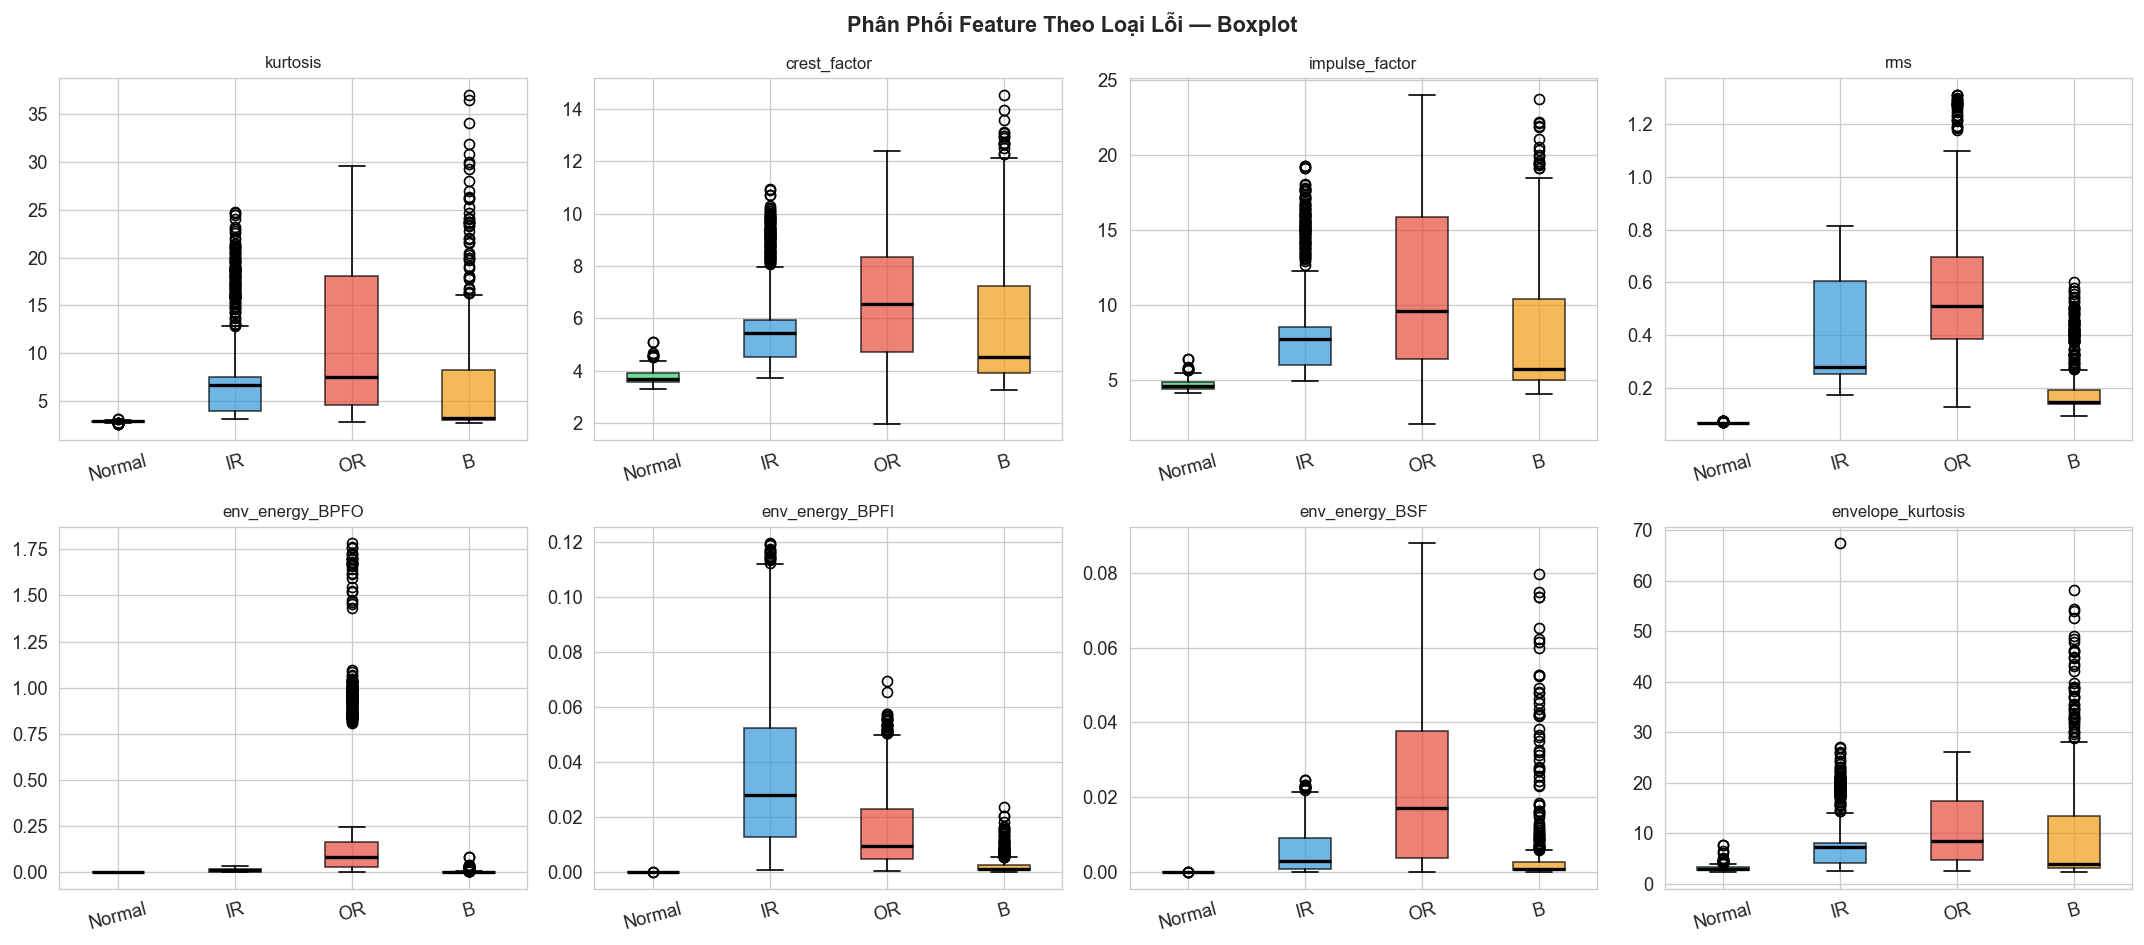

In [5]:
key_features = ['kurtosis', 'crest_factor', 'impulse_factor', 'rms',
                'env_energy_BPFO', 'env_energy_BPFI', 'env_energy_BSF', 'envelope_kurtosis']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
fig.suptitle('Phân Phối Feature Theo Loại Lỗi — Boxplot', fontsize=13, fontweight='bold')

for i, feat in enumerate(key_features):
    if feat not in df_features.columns:
        continue
    data_by_class = [df_features[df_features['label']==lbl][feat].values for lbl in CLASS_NAMES]
    bp = axes[i].boxplot(data_by_class, patch_artist=True, notch=False,
                          medianprops=dict(color='black', lw=2))
    for patch, lbl in zip(bp['boxes'], CLASS_NAMES):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)
    axes[i].set_xticklabels(CLASS_NAMES, rotation=15)
    axes[i].set_title(feat, fontsize=10)

plt.tight_layout()
plt.savefig('../figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔎 Đọc Boxplot Như Kỹ Sư

- **kurtosis:** Tách biệt rõ Normal vs các lỗi. Kurtosis > 6 → có xung va chạm.
- **env_energy_BPFO:** Rất cao ở OR → xác nhận lỗi rãnh ngoài (BPFO=107Hz ở dải **0-500Hz**).
- **env_energy_BPFI:** Cao ở IR → lỗi rãnh trong.
- **rms:** Tăng với lỗi nặng nhưng không phân biệt được loại lỗi cụ thể.

> 💡 **Bài học:** Envelope features (env_energy_*) phân biệt LOẠI lỗi, trong khi time-domain features (kurtosis, rms) chỉ phát hiện CÓ lỗi hay không.

In [6]:
# Lưu features để dùng ở Tutorial 04
df_features.to_csv('../notebooks/features_all.csv', index=False)
print("✅ Đã lưu features_all.csv")

✅ Đã lưu features_all.csv


---
*Tutorial 03 hoàn tất. Tiếp theo: Tutorial 04 — Huấn Luyện SVM & Random Forest.*